### Importing Librairs
---

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Reading Dataset
---

In [2]:
df = pd.read_csv("student_data.csv")
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


### Basic EDA
---


In [ ]:
df.head()       # First 5 rows

df.info()       # General info about df
df.items()

df.describe() 
df.index       


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

RangeIndex(start=0, stop=395, step=1)

In [40]:
variables = list(df.columns)        # Columns illustrating variables

In [4]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
df.shape
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

### Data Cleaning
---

In [35]:
df_clean = df.copy()

### Label Encoder Implementation for bianry columns
---

In [36]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
               'schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] =le.fit_transform(df_clean[col])

df_clean = pd.get_dummies(df_clean, columns=['Mjob', 'Fjob', 'reason', 'guardian'])
df_clean.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_OTHER,Fjob_SERVICES,Fjob_TEACHER,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,False,False,True,True,False,False,False,False,True,False
1,0,0,17,1,0,1,1,1,1,2,...,True,False,False,True,False,False,False,True,False,False
2,0,0,15,1,1,1,1,1,1,2,...,True,False,False,False,False,True,False,False,True,False
3,0,0,15,1,0,1,4,2,1,3,...,False,True,False,False,True,False,False,False,True,False
4,0,0,16,1,0,1,3,3,1,2,...,True,False,False,False,True,False,False,True,False,False


### Addresses 
---

In [42]:
env = set(df['address'] )
print(env)

{'R', 'U'}


### Rural vs Urban study hours
---

In [49]:
df.groupby(["address", 'studytime']).size().unstack()

studytime,1,2,3,4
address,,,,
R,27,35,19,7
U,78,163,46,20


In [14]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [15]:
df[(df['address']=='U')& (df['Fjob'] == "services")]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
12,GP,M,15,U,LE3,T,4,4,health,services,...,4,3,3,1,3,5,2,14,14,14
16,GP,F,16,U,GT3,T,4,4,services,services,...,3,2,3,1,2,2,6,13,14,14
18,GP,M,17,U,GT3,T,3,2,services,services,...,5,5,5,2,4,5,16,6,5,5
25,GP,F,16,U,GT3,T,2,2,services,services,...,1,2,2,1,3,5,14,6,9,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,MS,F,19,U,LE3,T,3,2,services,services,...,3,2,2,1,1,3,4,7,7,9
382,MS,M,17,U,GT3,T,2,3,other,services,...,4,4,3,1,1,3,2,11,11,10
388,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,0,7,9,8
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9


In [16]:
df[df['Medu'] >3]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
10,GP,F,15,U,GT3,T,4,4,teacher,health,...,3,3,3,1,2,2,0,10,8,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,MS,F,20,U,GT3,T,4,2,health,other,...,5,4,3,1,1,3,4,15,14,15
377,MS,F,18,R,LE3,T,4,4,teacher,services,...,5,4,3,3,4,2,4,8,9,10
380,MS,M,18,U,GT3,T,4,4,teacher,teacher,...,3,2,4,1,4,2,4,15,14,14
384,MS,M,18,R,GT3,T,4,2,other,other,...,5,4,3,4,3,3,14,6,5,5


In [20]:
# Average G3 by whether they want higher education


df.groupby('higher')['G3'].mean()

higher
no      6.800
yes    10.608
Name: G3, dtype: float64

In [21]:
# Students with 0 failures and high study time

df[(df['failures'] == 0) & (df['studytime'] >=3 )]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
3,GP,F,15,U,GT3,T,4,2,health,SERVICES,...,3,2,2,1,1,5,2,15,14,15
11,GP,F,15,U,GT3,T,2,1,services,OTHER,...,5,2,2,1,1,4,4,10,12,12
14,GP,M,15,U,GT3,A,2,2,other,OTHER,...,4,5,2,1,1,3,0,14,16,16
16,GP,F,16,U,GT3,T,4,4,services,SERVICES,...,3,2,3,1,2,2,6,13,14,14
24,GP,F,15,R,GT3,T,2,4,services,HEALTH,...,4,3,2,1,1,5,2,10,9,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,MS,M,18,U,LE3,T,4,4,teacher,SERVICES,...,4,2,2,2,2,5,0,13,13,13
372,MS,F,17,U,GT3,T,2,2,other,AT_HOME,...,3,4,3,1,1,3,8,13,11,11
374,MS,F,18,R,LE3,T,4,4,other,OTHER,...,5,4,4,1,1,1,0,19,18,19
375,MS,F,18,R,GT3,T,1,1,other,OTHER,...,4,3,2,1,2,4,2,8,8,10


### Final Grades Distribution
---

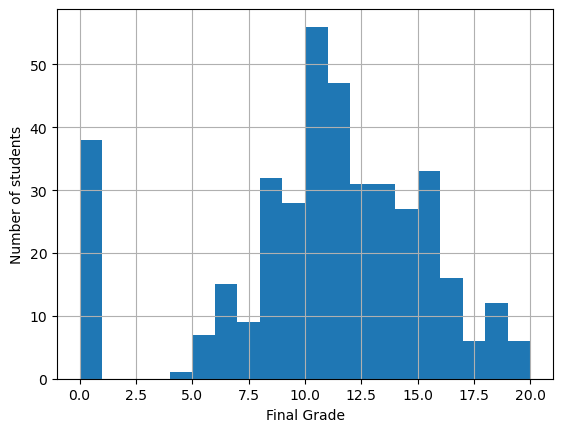

In [50]:
df['G3'].hist(bins=20)
plt.xlabel("Final Grade")
plt.ylabel("Number of students")
plt.savefig('gpa_dist.png')
plt.show()

### 

### Study Time vs Final Grade

---

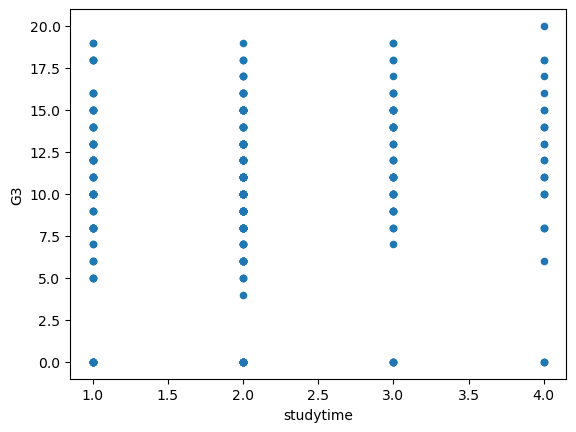

In [51]:
df.plot.scatter(x='studytime', y='G3')
plt.savefig('studytime_and_G3.png')

In [31]:
# Method 1 — single number between two columns
df['studytime'].corr(df['G3'])
# → 0.25  (weak positive correlation)

# Method 2 — full correlation table for all numeric columns
df.corr(numeric_only=True)

# Method 3 — just the columns you care about
df[['studytime', 'G3', 'failures', 'absences']].corr()

,studytime,G3,failures,absences
studytime,1.000000,0.097820,-0.173563,-0.062700
G3,0.097820,1.000000,-0.360415,0.034247
failures,-0.173563,-0.360415,1.000000,0.063726
absences,-0.062700,0.034247,0.063726,1.000000


### Failures vs Final Grade
---

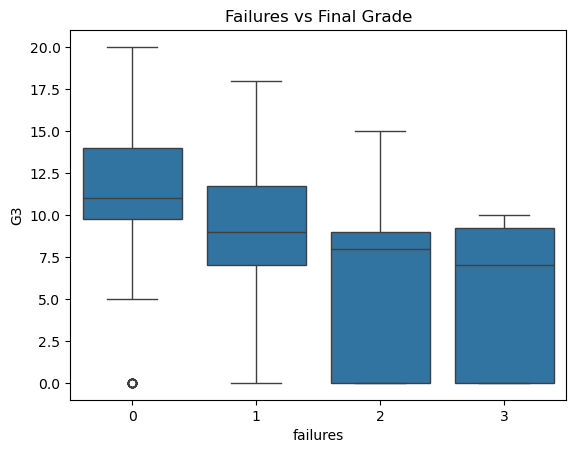

In [53]:
sns.boxplot(data=df_clean,
            x="failures",
            y="G3")
plt.title("Failures vs Final Grade")
plt.savefig('failures vs grade.png')
plt.show()

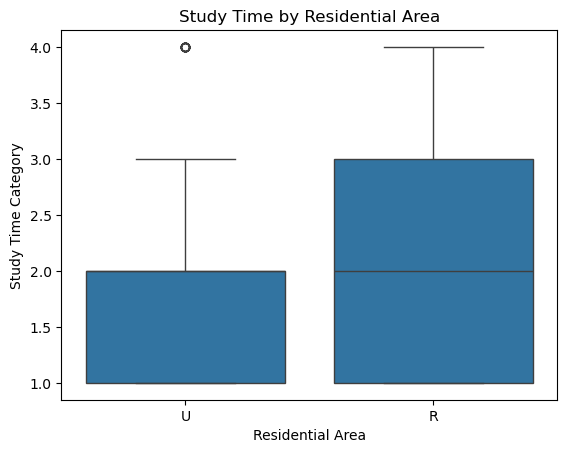

In [54]:
sns.boxplot(
    data=df,
    x='address',
    y='studytime'
)

plt.title('Study Time by Residential Area')
plt.xlabel('Residential Area')
plt.ylabel('Study Time Category')
plt.savefig('environment.png')
plt.show()